In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update(
    {
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 9,
    }
)
RANDOM_STATE=42
CSV_PATH="../data/diabetes.csv"
TARGET_COL="diabetes"

In [4]:
df=pd.read_csv(CSV_PATH)

In [5]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.000,0,1,never,25.190,6.600,140,0
1,Female,54.000,0,0,No Info,27.320,6.600,80,0
2,Male,28.000,0,0,never,27.320,5.700,158,0
3,Female,36.000,0,0,current,23.450,5.000,155,0
4,Male,76.000,1,1,current,20.140,4.800,155,0


In [7]:
df.shape

(100000, 9)

In [8]:
df.columns


Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [11]:
print("\nMissing Values")
print(df.isna().sum())


Missing Values
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Categorical Columns:",cat_cols)
print("Numerical Columns:",num_cols)
print("Target Column:",TARGET_COL)

Categorical Columns: ['gender', 'smoking_history']
Numerical Columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
Target Column: diabetes


In [14]:
duplicates=df.duplicated()
duplicates.drop_duplicates(inplace=True)

In [15]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,41.886,0.075,0.039,27.321,5.528,138.058,0.085
std,22.517,0.263,0.195,6.637,1.071,40.708,0.279
min,0.080,0.000,0.000,10.010,3.500,80.000,0.000
25%,24.000,0.000,0.000,23.630,4.800,100.000,0.000
50%,43.000,0.000,0.000,27.320,5.800,140.000,0.000
75%,60.000,0.000,0.000,29.580,6.200,159.000,0.000
max,80.000,1.000,1.000,95.690,9.000,300.000,1.000


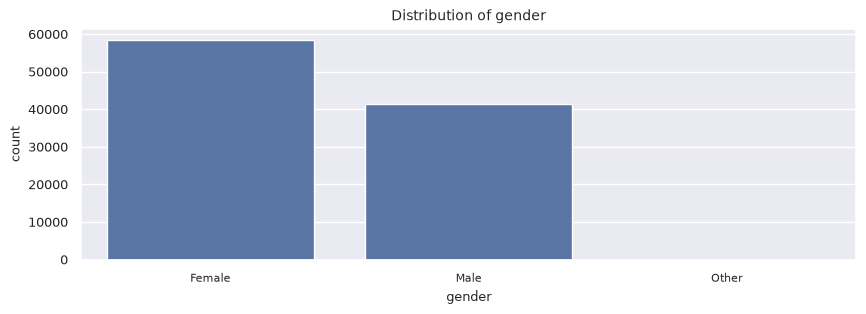

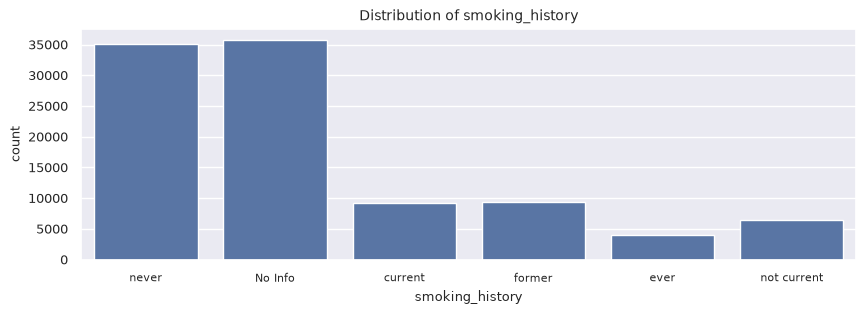

In [16]:
for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(x=col,data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [19]:
for col in cat_cols:
    print(df[col].value_counts())

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


Text(0.5, 1.0, 'Target distribution')

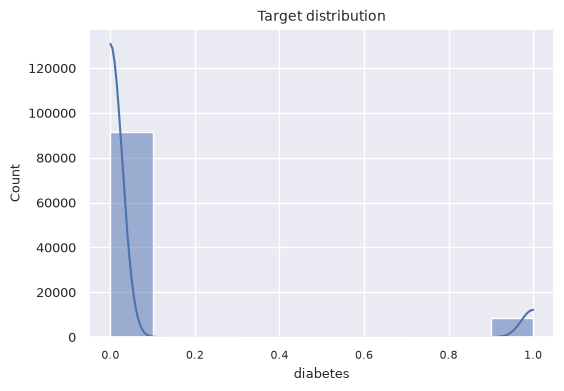

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL],bins=10,kde=True)
plt.title("Target distribution")

In [25]:
df[TARGET_COL].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64